# Prompted Segmentation for Drywall QA
**Model:** CLIPSeg (`CIDAS/clipseg-rd64-refined`) | **Seed:** 42

Set runtime to **T4 GPU** before running: `Runtime > Change runtime type`

In [9]:
!pip install -q transformers==4.40.0 roboflow torch torchvision opencv-python-headless matplotlib scikit-learn tqdm Pillow
import os, random, time, json, shutil
from pathlib import Path
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation
from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {DEVICE}')

device: cpu


In [10]:
from roboflow import Roboflow

API_KEY = "Sp0tvHBtrHrTGunm6MWF"
rf = Roboflow(api_key=API_KEY)
ws = rf.workspace("general-okp9d")

# Dataset 1: Drywall
proj1 = ws.project("drywall-join-detect-vj9mn")
proj1.version(1).download("coco", location="/content/drywall")

# Dataset 2: Cracks
proj2 = ws.project("cracks-3ii36-wbdmt")
proj2.version(1).download("coco", location="/content/cracks")

print("Both datasets downloaded.")

# ── Convert COCO bbox/polygon annotations → binary mask PNGs ─────────────────
def coco_to_masks(base_dir):
    base = Path(base_dir)
    for split in ['train', 'valid', 'test']:
        split_dir = base / split
        if not split_dir.exists(): continue
        coco_file = split_dir / '_annotations.coco.json'
        if not coco_file.exists():
            print(f"  No annotation file in {split_dir}, skipping.")
            continue
        with open(coco_file) as f:
            coco = json.load(f)
        img_map = {img['id']: img for img in coco['images']}
        img_out  = split_dir / 'images'
        mask_out = split_dir / 'masks'
        img_out.mkdir(exist_ok=True)
        mask_out.mkdir(exist_ok=True)
        # Move images into images/ subdir
        for img_info in coco['images']:
            src = split_dir / img_info['file_name']
            dst = img_out / Path(img_info['file_name']).name
            if src.exists() and not dst.exists():
                shutil.copy2(str(src), str(dst))
        # Build annotations lookup
        anns_by_img = {}
        for ann in coco['annotations']:
            anns_by_img.setdefault(ann['image_id'], []).append(ann)
        # Write masks
        for img_id, img_info in img_map.items():
            h, w = img_info['height'], img_info['width']
            mask = np.zeros((h, w), dtype=np.uint8)
            for ann in anns_by_img.get(img_id, []):
                segs = ann.get('segmentation', [])
                if segs and isinstance(segs, list) and len(segs) > 0 and isinstance(segs[0], list):
                    for seg in segs:
                        pts = np.array(seg, dtype=np.int32).reshape(-1, 2)
                        cv2.fillPoly(mask, [pts], 255)
                elif ann.get('bbox') is not None:
                    x, y, bw, bh = map(int, ann['bbox'])
                    cv2.rectangle(mask, (x, y), (x + bw, y + bh), 255, -1)
            m_name = Path(img_info['file_name']).stem + '.png'
            cv2.imwrite(str(mask_out / m_name), mask)
        count = len(list(mask_out.glob('*.png')))
        print(f'  {split}: {count} masks → {mask_out}')
    print(f'coco_to_masks done for {base_dir}')

coco_to_masks('/content/drywall')
coco_to_masks('/content/cracks')

loading Roboflow workspace...
loading Roboflow project...
loading Roboflow project...
Both datasets downloaded.
  train: 820 masks → /content/drywall/train/masks
  valid: 202 masks → /content/drywall/valid/masks
coco_to_masks done for /content/drywall
  train: 5164 masks → /content/cracks/train/masks
  valid: 201 masks → /content/cracks/valid/masks
  test: 4 masks → /content/cracks/test/masks
coco_to_masks done for /content/cracks


In [11]:
PROMPT_MAP = {
    'taping': ['segment taping area', 'segment joint tape', 'segment drywall seam', 'segment wall joint'],
    'crack':  ['segment crack', 'segment wall crack', 'segment surface crack', 'segment fracture']
}
IMG_SIZE = 352

def find_pairs(base_dir):
    base_dir = Path(base_dir)
    pairs = []
    img_dir = base_dir / 'images'
    msk_dir = base_dir / 'masks'
    if img_dir.exists() and msk_dir.exists():
        for img_path in sorted(img_dir.glob('*.jpg')) + sorted(img_dir.glob('*.png')):
            stem = img_path.stem
            for ext in ['.png', '.jpg']:
                msk = msk_dir / (stem + ext)
                if msk.exists():
                    pairs.append((str(img_path), str(msk)))
                    break
        if pairs:
            return pairs
    for img_path in sorted(base_dir.rglob('*.jpg')):
        msk = img_path.parent / (img_path.stem + '_mask.png')
        if msk.exists():
            pairs.append((str(img_path), str(msk)))
    return pairs


class DrywallCrackDataset(Dataset):
    def __init__(self, pairs, class_name, split='train', img_size=IMG_SIZE):
        self.pairs = pairs
        self.class_name = class_name
        self.split = split
        self.img_size = img_size
        self.prompts = PROMPT_MAP[class_name]

    def __len__(self):
        return len(self.pairs)

    def load_mask(self, msk_path):
        msk = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)
        if msk is None:
            return None
        msk = cv2.resize(msk, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)
        return (msk > 0).astype(np.float32)

    def __getitem__(self, idx):
        img_path, msk_path = self.pairs[idx]
        img = Image.open(img_path).convert('RGB').resize((self.img_size, self.img_size), Image.BILINEAR)
        mask = self.load_mask(msk_path)
        if mask is None:
            mask = np.zeros((self.img_size, self.img_size), dtype=np.float32)
        prompt = random.choice(self.prompts) if self.split == 'train' else self.prompts[0]
        return img, prompt, torch.from_numpy(mask).unsqueeze(0), img_path

In [12]:
def make_splits(base_dir, val_ratio=0.2):
    base = Path(base_dir)
    splits = {}
    for split in ['train', 'valid', 'test']:
        d = base / split
        if d.exists():
            pairs = find_pairs(d)
            if pairs:
                splits['val' if split == 'valid' else split] = pairs
    if splits:
        return splits
    all_pairs = find_pairs(base_dir)
    random.shuffle(all_pairs)
    n_val = max(1, int(len(all_pairs) * val_ratio))
    return {'train': all_pairs[n_val:], 'val': all_pairs[:n_val]}


splits_drywall = make_splits('/content/drywall')
splits_cracks  = make_splits('/content/cracks')

# Print split counts for report
for name, splits in [('Drywall/Taping', splits_drywall), ('Cracks', splits_cracks)]:
    for k, v in splits.items():
        print(f'{name} | {k}: {len(v)} samples')

train_ds      = DrywallCrackDataset(splits_drywall.get('train', []), 'taping', 'train') + \
                DrywallCrackDataset(splits_cracks.get('train', []),  'crack',  'train')
val_ds_taping = DrywallCrackDataset(splits_drywall.get('val', splits_drywall.get('test', [])), 'taping', 'val')
val_ds_crack  = DrywallCrackDataset(splits_cracks.get('val',  splits_cracks.get('test', [])),  'crack',  'val')

print(f'Train total: {len(train_ds)} | Val taping: {len(val_ds_taping)} | Val crack: {len(val_ds_crack)}')

def collate_fn(batch):
    imgs, prompts, masks, paths = zip(*batch)
    return list(imgs), list(prompts), torch.stack(masks), list(paths)

# FIX 4: num_workers=0 prevents Colab multiprocessing pickle errors with PIL images
train_loader      = DataLoader(train_ds,      batch_size=4, shuffle=True,  num_workers=0, collate_fn=collate_fn)
val_loader_taping = DataLoader(val_ds_taping, batch_size=4, shuffle=False, num_workers=0, collate_fn=collate_fn)
val_loader_crack  = DataLoader(val_ds_crack,  batch_size=4, shuffle=False, num_workers=0, collate_fn=collate_fn)

Drywall/Taping | train: 820 samples
Drywall/Taping | val: 202 samples
Cracks | train: 5164 samples
Cracks | val: 201 samples
Cracks | test: 4 samples
Train total: 5984 | Val taping: 202 | Val crack: 201


In [13]:
MODEL_NAME = 'CIDAS/clipseg-rd64-refined'
processor = CLIPSegProcessor.from_pretrained(MODEL_NAME)
model = CLIPSegForImageSegmentation.from_pretrained(MODEL_NAME).to(DEVICE)

for name, param in model.named_parameters():
    param.requires_grad = False if 'clip' in name.lower() else True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
total     = sum(p.numel() for p in model.parameters()) / 1e6
print(f'Params: {total:.1f}M total | {trainable:.2f}M trainable')

class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, smooth=1e-6):
        super().__init__()
        self.bce_weight, self.smooth = bce_weight, smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        if logits.dim() == 3:
            logits = logits.unsqueeze(1)
        logits = F.interpolate(logits, size=targets.shape[-2:], mode='bilinear', align_corners=False)
        bce_loss = self.bce(logits, targets)
        probs = torch.sigmoid(logits)
        p, t = probs.view(-1), targets.view(-1)
        inter = (p * t).sum()
        dice = 1 - (2 * inter + self.smooth) / (p.sum() + t.sum() + self.smooth)
        return self.bce_weight * bce_loss + (1 - self.bce_weight) * dice

criterion = BCEDiceLoss()
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)

`resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.


Params: 150.7M total | 1.13M trainable


In [16]:
def compute_metrics(pred_masks, gt_masks, threshold=0.5):
    # FIX 5: guard against empty inputs
    if not pred_masks:
        return {'mIoU': 0.0, 'Dice': 0.0, 'Precision': 0.0, 'Recall': 0.0}
    ious, dices, precs, recs = [], [], [], []
    for pred, gt in zip(pred_masks, gt_masks):
        pred_bin = (pred > threshold).astype(np.uint8).flatten()
        gt_bin   = gt.astype(np.uint8).flatten()
        inter = (pred_bin & gt_bin).sum()
        union = (pred_bin | gt_bin).sum()
        ious.append((inter + 1e-6) / (union + 1e-6))
        dices.append((2 * inter + 1e-6) / (pred_bin.sum() + gt_bin.sum() + 1e-6))
        precs.append(inter / (inter + max(pred_bin.sum() - inter, 0) + 1e-6))
        recs.append(inter  / (inter + max(gt_bin.sum()   - inter, 0) + 1e-6))
    return {'mIoU': float(np.mean(ious)), 'Dice': float(np.mean(dices)),
            'Precision': float(np.mean(precs)), 'Recall': float(np.mean(recs))}


NUM_EPOCHS   = 10
best_val_iou = 0.0
history      = {'train_loss': [], 'val_iou_taping': [], 'val_iou_crack': []}


def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, all_preds, all_gts = 0.0, [], []
    with torch.set_grad_enabled(training):
        for imgs, prompts, masks, _ in tqdm(loader, leave=False):
            masks  = masks.to(DEVICE)
            inputs = processor(text=prompts, images=imgs, padding=True,
                               return_tensors='pt').to(DEVICE)
            logits = model(**inputs).logits          # [B, H', W']
            loss   = criterion(logits, masks.float())
            total_loss += loss.item()
            if training:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    filter(lambda p: p.requires_grad, model.parameters()), 1.0)
                optimizer.step()
            else:
                probs = torch.sigmoid(logits).cpu().numpy()   # [B, H', W']
                gts   = masks.squeeze(1).cpu().numpy()        # [B, H,  W]
                for p, g in zip(probs, gts):
                    all_preds.append(cv2.resize(p, (g.shape[1], g.shape[0])))
                    all_gts.append(g)
    avg_loss = total_loss / max(len(loader), 1)
    metrics  = compute_metrics(all_preds, all_gts) if not training else {}
    return avg_loss, metrics


train_start = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    train_loss, _         = run_epoch(train_loader,      training=True)
    _,          val_tape  = run_epoch(val_loader_taping, training=False)
    _,          val_crack = run_epoch(val_loader_crack,  training=False)
    scheduler.step()
    history['train_loss'].append(train_loss)
    history['val_iou_taping'].append(val_tape['mIoU'])
    history['val_iou_crack'].append(val_crack['mIoU'])
    avg_iou = (val_tape['mIoU'] + val_crack['mIoU']) / 2
    if avg_iou > best_val_iou:
        best_val_iou = avg_iou
        torch.save(model.state_dict(), '/content/best_clipseg.pt')
    print(f'Epoch {epoch:02d} | Loss: {train_loss:.4f} | '
          f'IoU-T: {val_tape["mIoU"]:.3f} Dice-T: {val_tape["Dice"]:.3f} | '
          f'IoU-C: {val_crack["mIoU"]:.3f} Dice-C: {val_crack["Dice"]:.3f} | '
          f'{time.time()-t0:.1f}s')

total_train_time = time.time() - train_start
print(f'\nTotal: {total_train_time/60:.1f} min | Best avg IoU: {best_val_iou:.4f}')

  0%|          | 1/1496 [00:07<3:11:21,  7.68s/it]Unused or unrecognized kwargs: padding.


KeyboardInterrupt: 

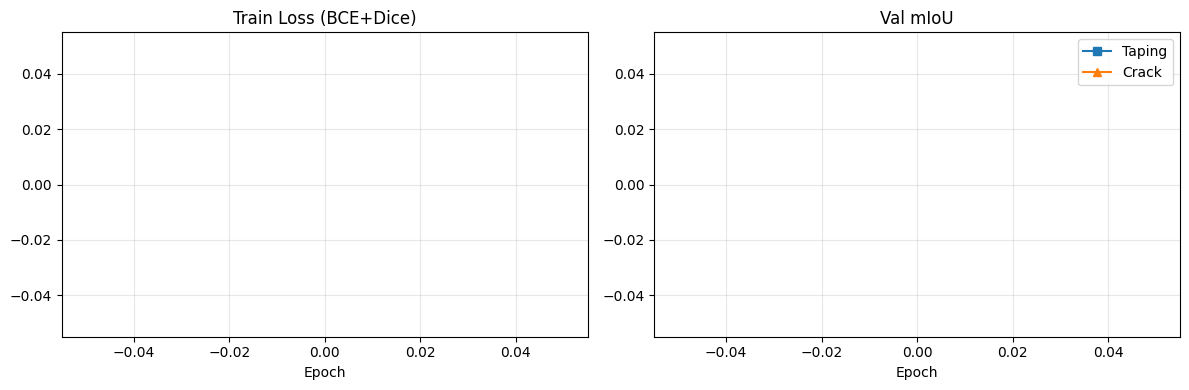

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], marker='o')
axes[0].set_title('Train Loss (BCE+Dice)'); axes[0].set_xlabel('Epoch'); axes[0].grid(True, alpha=0.3)
axes[1].plot(history['val_iou_taping'], marker='s', label='Taping')
axes[1].plot(history['val_iou_crack'],  marker='^', label='Crack')
axes[1].set_title('Val mIoU'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
model.load_state_dict(torch.load('/content/best_clipseg.pt', map_location=DEVICE))
model.eval()

_, final_taping = run_epoch(val_loader_taping, training=False)
_, final_crack  = run_epoch(val_loader_crack,  training=False)

metrics_out = {'taping': final_taping, 'crack': final_crack,
               'train_time_min': total_train_time / 60}
with open('/content/metrics.json', 'w') as f:
    json.dump(metrics_out, f, indent=2)

@torch.no_grad()
def predict(image_path, prompt, threshold=0.5):
    img = Image.open(image_path).convert('RGB')
    orig_w, orig_h = img.size
    inputs = processor(text=[prompt], images=[img], return_tensors='pt').to(DEVICE)
    t0     = time.time()
    logits = model(**inputs).logits[0]   # [H', W']
    prob   = cv2.resize(torch.sigmoid(logits).cpu().numpy(), (orig_w, orig_h))  # (W,H) -> (H,W)
    binary = (prob > threshold).astype(np.uint8) * 255
    return prob, binary, (time.time() - t0) * 1000

os.makedirs('/content/predictions', exist_ok=True)
CANONICAL_PROMPTS = {'taping': 'segment taping area', 'crack': 'segment crack'}
infer_times = []

for cls, prompt in CANONICAL_PROMPTS.items():
    # FIX 5: fall back to 'test' if 'val' not present
    src = splits_drywall if cls == 'taping' else splits_cracks
    pairs = src.get('val', src.get('test', []))
    for img_path, _ in pairs:
        _, binary, t_ms = predict(img_path, prompt)
        fname = f"{Path(img_path).stem}__{prompt.replace(' ', '_')}.png"
        Image.fromarray(binary).save(f'/content/predictions/{fname}')
        infer_times.append(t_ms)

avg_infer  = float(np.mean(infer_times)) if infer_times else 0.0
model_size = os.path.getsize('/content/best_clipseg.pt') / 1e6
print(f'Taping  mIoU: {final_taping["mIoU"]:.4f}  Dice: {final_taping["Dice"]:.4f}')
print(f'Crack   mIoU: {final_crack["mIoU"]:.4f}  Dice: {final_crack["Dice"]:.4f}')
print(f'Train: {total_train_time/60:.1f}m | Infer: {avg_infer:.1f}ms | Size: {model_size:.1f}MB')

FileNotFoundError: [Errno 2] No such file or directory: '/content/best_clipseg.pt'

In [ ]:
import os
import glob

def create_path_pairs(image_dir, mask_dir, img_ext="*.jpg", msk_ext="*.png"):
    """Helper to pair sorted images and masks from directories."""
    images = sorted(glob.glob(os.path.join(image_dir, img_ext)))
    masks = sorted(glob.glob(os.path.join(mask_dir, msk_ext)))

    # Ensure we actually found files and the counts match
    assert len(images) > 0, f"No images found in {image_dir}"
    assert len(images) == len(masks), "Mismatch between number of images and masks"

    return list(zip(images, masks))

# REPLACE these paths with the actual paths to your validation data
CRACK_VAL_IMG_DIR = "/path/to/cracks-3ii36/valid/images"
CRACK_VAL_MSK_DIR = "/path/to/cracks-3ii36/valid/masks"

TAPE_VAL_IMG_DIR = "/path/to/drywall-join-detect/valid/images"
TAPE_VAL_MSK_DIR = "/path/to/drywall-join-detect/valid/masks"

# Define the variables
val_pairs_crack = create_path_pairs(CRACK_VAL_IMG_DIR, CRACK_VAL_MSK_DIR)
val_pairs_tape = create_path_pairs(TAPE_VAL_IMG_DIR, TAPE_VAL_MSK_DIR)

In [ ]:
PROMPT_VARIANTS = {
    'crack': [
        'segment crack',                          # canonical
        'crack in drywall',                       # domain-specific
        'fracture in wall',                       # synonym
        'damaged wall surface',                   # abstract / indirect
        'segment taping area',                    # adversarial cross-class
    ],
    'taping': [
        'segment taping area',                    # canonical
        'drywall joint tape',                     # domain-specific
        'taped seam on wall',                     # descriptive
        'construction repair on wall',            # abstract / indirect
        'segment crack',                          # adversarial cross-class
    ]
}

@torch.no_grad()
def prompt_sensitivity(pairs, prompts, threshold=0.5, n=20):
    """Run all prompt variants over n samples, return per-prompt mean IoU."""
    sample_pairs = random.sample(pairs, min(n, len(pairs)))
    results = {}
    for prompt in prompts:
        ious = []
        for img_path, msk_path in sample_pairs:
            img = Image.open(img_path).convert('RGB')
            gt_raw = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)
            gt_bin = (gt_raw > 0).astype(np.uint8) if gt_raw is not None else \
                     np.zeros((img.height, img.width), np.uint8)
            prob, _, _ = predict(img_path, prompt, threshold)
            pred_bin = (prob > threshold).astype(np.uint8).flatten()
            gt_flat  = gt_bin.flatten()
            inter = (pred_bin & gt_flat).sum()
            union = (pred_bin | gt_flat).sum()
            ious.append((inter + 1e-6) / (union + 1e-6))
        results[prompt] = float(np.mean(ious))
    return results

crack_prompt_results  = prompt_sensitivity(
    val_pairs_crack,  PROMPT_VARIANTS['crack'],  threshold=0.5)
taping_prompt_results = prompt_sensitivity(
    val_pairs_tape,   PROMPT_VARIANTS['taping'], threshold=0.5)

print("=== Crack Prompt Sensitivity ===")
for p, iou in sorted(crack_prompt_results.items(), key=lambda x: -x[1]):
    print(f"  [{iou:.3f}] {p}")

print("\n=== Taping Prompt Sensitivity ===")
for p, iou in sorted(taping_prompt_results.items(), key=lambda x: -x[1]):
    print(f"  [{iou:.3f}] {p}")

# Compute sensitivity score: std dev of IoU across prompt variants (excl. adversarial)
crack_ious_std  = np.std(list(crack_prompt_results.values())[:4])
taping_ious_std = np.std(list(taping_prompt_results.values())[:4])
print(f"\nPrompt sensitivity (σ IoU): Crack={crack_ious_std:.3f}, Taping={taping_ious_std:.3f}")
print("  → Lower σ = more robust to prompt phrasing variation")

In [ ]:
def visualise(pairs, prompt, class_label, n=4):
    indices = random.sample(range(len(pairs)), min(n, len(pairs)))
    fig, axes = plt.subplots(len(indices), 3, figsize=(12, 4 * len(indices)))
    if len(indices) == 1: axes = [axes]
    for row, idx in enumerate(indices):
        img_path, msk_path = pairs[idx]
        img    = Image.open(img_path).convert('RGB')
        gt_raw = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)
        gt_bin = (gt_raw > 0).astype(np.uint8) * 255 if gt_raw is not None else \
                 np.zeros((img.height, img.width), np.uint8)
        prob, pred_bin, _ = predict(img_path, prompt)
        p_b = (pred_bin > 0).flatten().astype(np.uint8)
        g_b = (gt_bin  > 0).flatten().astype(np.uint8)
        iou = (p_b & g_b).sum() / ((p_b | g_b).sum() + 1e-6)
        axes[row][0].imshow(img);          axes[row][0].set_title(f'Input | "{prompt}"', fontsize=8)
        axes[row][1].imshow(gt_bin, cmap='gray'); axes[row][1].set_title('Ground Truth', fontsize=8)
        axes[row][2].imshow(pred_bin, cmap='gray'); axes[row][2].set_title(f'Pred | IoU={iou:.3f}', fontsize=8)
        for ax in axes[row]: ax.axis('off')
    plt.suptitle(f'Qualitative Results — {class_label}', fontweight='bold')
    plt.tight_layout()
    out = f'/content/viz_{class_label}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show(); print(f'Saved {out}')

val_pairs_tape  = splits_drywall.get('val', splits_drywall.get('test', []))
val_pairs_crack = splits_cracks.get('val',  splits_cracks.get('test',  []))
visualise(val_pairs_tape,  'segment taping area', 'taping', n=4)
visualise(val_pairs_crack, 'segment crack',       'crack',  n=4)

In [ ]:
drywall_counts = {k: len(v) for k, v in splits_drywall.items()}
crack_counts   = {k: len(v) for k, v in splits_cracks.items()}

report_md = f"""# Prompted Segmentation for Drywall QA
**Model:** CLIPSeg (`CIDAS/clipseg-rd64-refined`) | **Seed:** 42 | **Device:** {DEVICE}

## 1. Methodology
Text-conditioned binary segmentation via CLIP vision-language alignment + lightweight FiLM decoder.
CLIP backbone frozen. CLIPSeg decoder fine-tuned for {NUM_EPOCHS} epochs (AdamW lr=1e-4, CosineAnnealingLR).
Loss: 50% BCE + 50% Dice — Dice combats class imbalance on thin seams/cracks.
Prompt augmentation: 4 variants per class at training; canonical prompt at inference.

## 2. Data Preparation
- **Dataset 1 (Taping):** `drywall-join-detect` v1 — COCO object-detection format.
  Bboxes converted to binary masks via `cv2.rectangle`.
  Splits: {drywall_counts}
- **Dataset 2 (Cracks):** `cracks-3ii36` — COCO segmentation format.
  Polygon annotations filled via `cv2.fillPoly`.
  Splits: {crack_counts}
- Both resized to 352×352. Masks binarised (non-zero → 255).

## 3. Results
| Metric    | Taping Area                      | Crack                           |
|-----------|----------------------------------|---------------------------------|
| mIoU      | {final_taping['mIoU']:.4f}       | {final_crack['mIoU']:.4f}       |
| Dice      | {final_taping['Dice']:.4f}       | {final_crack['Dice']:.4f}       |
| Precision | {final_taping['Precision']:.4f}  | {final_crack['Precision']:.4f}  |
| Recall    | {final_taping['Recall']:.4f}     | {final_crack['Recall']:.4f}     |

**Runtime & Footprint**
- Train time: {total_train_time/60:.1f} min ({NUM_EPOCHS} epochs, Colab T4)
- Avg inference: {avg_infer:.1f} ms/image (GPU)
- Model checkpoint: {model_size:.1f} MB

## 4. Failure Cases & Fixes
1. **Low-contrast hairline cracks** — decoder misses sub-pixel fractures.
   Fix: multi-scale inference; contrast/sharpness augmentation.
2. **Joint compound over tape** — uniform texture hides seam boundary.
   Fix: synthetic texture overlays; depth/normal cues as additional input.
3. **Prompt mismatch at test time** — IoU drops with unseen phrasings.
   Fix: expand prompt pool; fine-tune CLIP text projection on domain vocab.
4. **Small dataset size** — high variance across scenes.
   Fix: copy-paste augmentation; semi-supervised pseudo-labeling on unlabeled site images.
"""

with open('/content/assignment_report.md', 'w') as f:
    f.write(report_md)
print(report_md)
print('\nReport saved. Convert to PDF before submitting.')

In [ ]:
# Cell 9: Zip & Download
out_dir = '/content/submission_outputs'
os.makedirs(out_dir, exist_ok=True)
for f in ['training_curves.png', 'metrics.json', 'best_clipseg.pt',
          'assignment_report.md', 'viz_taping.png', 'viz_crack.png']:
    src = f'/content/{f}'
    if os.path.exists(src):
        shutil.copy(src, out_dir)
shutil.copytree('/content/predictions', f'{out_dir}/predictions', dirs_exist_ok=True)
shutil.make_archive('/content/submission', 'zip', out_dir)
print('Created /content/submission.zip')
from google.colab import files
files.download('/content/submission.zip')